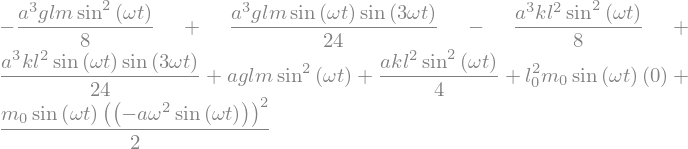

In [14]:
from sympy import *
import sympy as sym
from sympy.physics.mechanics import *
from sympy import init_printing
mechanics_printing(pretty_print=True)

t=Symbol('t')
m,k,l,g=symbols('m k l g',positive=True)
a,omg,m0,k0,l0, d=symbols('a omega m0 k0 l0 d',positive=True)
phi=dynamicsymbols('\\varphi')
dphi=dynamicsymbols('\\varphi',1)
d2phi=dynamicsymbols('\\varphi',2)

x = l*sin(phi)
y = l*cos(phi)
v = sqrt(x.diff(t)**2 + y.diff(t)**2)


T = l0**2*m0*dphi**2/2
V = k*((l/2)*sin(phi))**2/2+m*g*l*(1-cos(phi))

L = T.simplify() - V




dL_dphi = diff(L,phi)
dL_dphi_dot = diff(L,dphi)
dt_dL_dphi_dot = diff(dL_dphi_dot,t)

RR = dt_dL_dphi_dot - dL_dphi

dRR_dt = diff(RR,phi,1).subs({phi:0}).doit()
d2RR_dt = diff(RR,phi,2).subs({phi:0}).doit()
d3RR_dt = diff(RR,phi,3).subs({phi:0}).doit()

RR0 = RR.subs(phi,0)

RRT = RR0+dRR_dt*phi +(d2RR_dt*phi**2)/2+((d3RR_dt)*phi**3)/6+m0*d2phi**2/2
RRT


phip = a*sin(omg*t)
dphip = diff(phip,t,1)
d2phip = diff(phip,t,2)

RRp = RRT.subs([(phi,phip),(dphip,dphip),(d2phi,d2phip),])

RRsimp = RRp.subs((sin(omg*t))**3, 3*sin(omg*t)/4-sin(3*omg*t)/4)
RRe = RRsimp.expand()
RRe

calk = RRe*sin(omg*t)
calk.expand()
